# EDA temporal - Dataset de consumo eléctrico

Este notebook se usa solo para exploración inicial. La implementación final de limpieza y transformación debe hacerse en Go dentro de `data-load/internal/dataset`.

Objetivo:
- Entender la estructura del dataset.
- Detectar valores faltantes o inválidos.
- Revisar rangos y outliers.
- Definir reglas de limpieza.
- Definir columnas transformadas útiles para ML.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 1. Cargar una muestra del dataset

Ajusta la ruta según dónde abras el notebook. Si lo colocas en `/notebooks`, probablemente la ruta sea `../data/raw/household_power_consumption.txt`.


In [10]:
DATA_PATH = Path('../data/raw/household_power_consumption.txt')

df = pd.read_csv(
    DATA_PATH,
    sep=';',
    low_memory=False
)

df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## 2. Estructura básica

In [11]:
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])
df.info()


Filas: 2075259
Columnas: 9
<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 239.1 MB


In [12]:
df.describe(include='all')

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2075259,2.049280e+06
unique,1442,1440,4187,533,2838,222,89,82,NaN
top,17/12/2006,17:24:00,?,0.000,?,1.000,0.000,0.000,NaN
freq,1440,1442,25979,481561,25979,172785,1880175,1436830,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.458447e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.437154e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000e+01


## 3. Detectar valores faltantes o inválidos

En este dataset es común encontrar `?` como valor faltante.


In [13]:
invalid_counts = (df == '?').sum().sort_values(ascending=False)
invalid_counts


Global_active_power      25979
Sub_metering_2           25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Date                         0
Time                         0
Sub_metering_3               0
dtype: int64

In [14]:
missing_percent = ((df == '?').sum() / len(df) * 100).sort_values(ascending=False)
missing_percent


Global_active_power      1.251844
Sub_metering_2           1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Date                     0.000000
Time                     0.000000
Sub_metering_3           0.000000
dtype: float64

## 4. Convertir columnas numéricas para análisis

Esto es solo para exploración. En Go se debe implementar la misma regla con `strconv.ParseFloat`.


In [15]:
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

eda = df.copy()

for col in numeric_cols:
    eda[col] = pd.to_numeric(eda[col], errors='coerce')

eda[numeric_cols].isna().sum().sort_values(ascending=False)


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

## 5. Revisar rangos numéricos

In [16]:
eda[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


## 6. Crear DateTime y variables temporales

In [17]:
eda['DateTime'] = pd.to_datetime(
    eda['Date'] + ' ' + eda['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

eda['Hour'] = eda['DateTime'].dt.hour
eda['DayOfWeek'] = eda['DateTime'].dt.dayofweek
eda['Month'] = eda['DateTime'].dt.month

eda[['Date', 'Time', 'DateTime', 'Hour', 'DayOfWeek', 'Month']].head()


,Date,Time,DateTime,Hour,DayOfWeek,Month
0,16/12/2006,17:24:00,2006-12-16 17:24:00,17,5,12
1,16/12/2006,17:25:00,2006-12-16 17:25:00,17,5,12
2,16/12/2006,17:26:00,2006-12-16 17:26:00,17,5,12
3,16/12/2006,17:27:00,2006-12-16 17:27:00,17,5,12
4,16/12/2006,17:28:00,2006-12-16 17:28:00,17,5,12


## 7. Crear variable de consumo no submedido

In [18]:
eda['TotalActiveEnergyPerMinute'] = eda['Global_active_power'] * 1000 / 60

eda['SubMeteringTotal'] = (
    eda['Sub_metering_1'] +
    eda['Sub_metering_2'] +
    eda['Sub_metering_3']
)

eda['OtherConsumption'] = eda['TotalActiveEnergyPerMinute'] - eda['SubMeteringTotal']

eda[['Global_active_power', 'TotalActiveEnergyPerMinute', 'SubMeteringTotal', 'OtherConsumption']].head()


,Global_active_power,TotalActiveEnergyPerMinute,SubMeteringTotal,OtherConsumption
0,4.216,70.266667,18.0,52.266667
1,5.360,89.333333,17.0,72.333333
2,5.374,89.566667,19.0,70.566667
3,5.388,89.800000,18.0,71.800000
4,3.666,61.100000,18.0,43.100000


## 8. Analizar consumo por hora

In [19]:
hourly = eda.groupby('Hour')['Global_active_power'].agg(['count', 'mean', 'median', 'max']).reset_index()
hourly


,Hour,count,mean,median,max
0,0,85491,0.659434,0.366,7.698
1,1,85440,0.539325,0.328,10.290
2,2,85439,0.480621,0.320,6.248
3,3,85428,0.444866,0.314,4.426
4,4,85317,0.443847,0.312,4.796
5,5,85260,0.453674,0.310,6.376
6,6,85259,0.791600,0.350,8.310
7,7,85284,1.502246,1.502,9.486
8,8,85295,1.461016,1.410,8.126
9,9,85316,1.331645,1.360,7.732


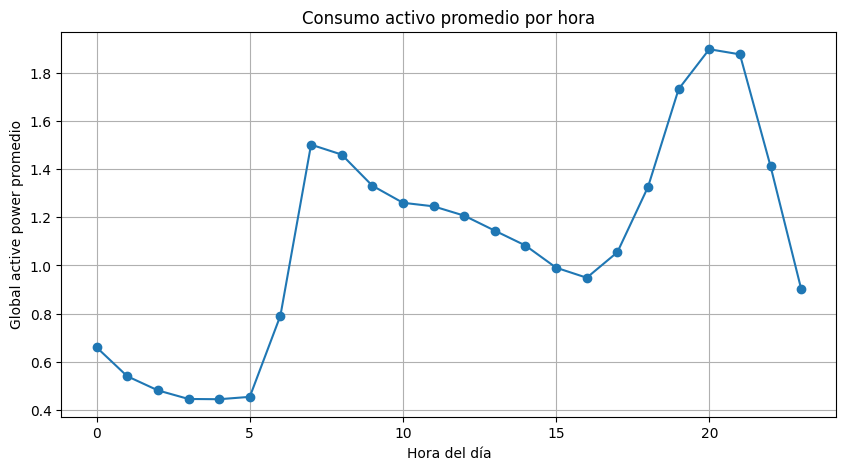

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(hourly['Hour'], hourly['mean'], marker='o')
plt.title('Consumo activo promedio por hora')
plt.xlabel('Hora del día')
plt.ylabel('Global active power promedio')
plt.grid(True)
plt.show()


## 9. Definir posible etiqueta para Machine Learning

In [21]:
threshold_p75 = eda['Global_active_power'].quantile(0.75)
threshold_p90 = eda['Global_active_power'].quantile(0.90)

print('P75:', threshold_p75)
print('P90:', threshold_p90)

eda['HighConsumptionP75'] = (eda['Global_active_power'] >= threshold_p75).astype(int)
eda['HighConsumptionP90'] = (eda['Global_active_power'] >= threshold_p90).astype(int)

eda[['Global_active_power', 'HighConsumptionP75', 'HighConsumptionP90']].head()


P75: 1.528
P90: 2.47


,Global_active_power,HighConsumptionP75,HighConsumptionP90
0,4.216,1,1
1,5.360,1,1
2,5.374,1,1
3,5.388,1,1
4,3.666,1,1


## 10. Reglas finales sugeridas para implementar en Go

In [22]:
summary = {
    'rows_sampled': len(df),
    'numeric_columns': numeric_cols,
    'invalid_question_mark_counts': invalid_counts.to_dict(),
    'missing_percent': missing_percent.to_dict(),
    'global_active_power_p75': float(threshold_p75),
    'global_active_power_p90': float(threshold_p90),
    'suggested_cleaning_rules': [
        'Descartar filas con columnas incompletas',
        'Descartar filas con ? en columnas numéricas',
        'Convertir columnas numéricas a float64',
        'Descartar filas con DateTime inválido',
        'Descartar filas con valores negativos en consumo o voltaje no positivo',
        'Crear Hour, DayOfWeek y Month desde DateTime',
        'Crear OtherConsumption = Global_active_power * 1000 / 60 - SubMeteringTotal',
        'Crear HighConsumption usando un umbral definido por percentil o regla de negocio'
    ]
}

summary


{'rows_sampled': 2075259,
 'numeric_columns': ['Global_active_power',
  'Global_reactive_power',
  'Voltage',
  'Global_intensity',
  'Sub_metering_1',
  'Sub_metering_2',
  'Sub_metering_3'],
 'invalid_question_mark_counts': {'Global_active_power': 25979,
  'Sub_metering_2': 25979,
  'Global_reactive_power': 25979,
  'Voltage': 25979,
  'Global_intensity': 25979,
  'Sub_metering_1': 25979,
  'Date': 0,
  'Time': 0,
  'Sub_metering_3': 0},
 'missing_percent': {'Global_active_power': 1.2518437457686005,
  'Sub_metering_2': 1.2518437457686005,
  'Global_reactive_power': 1.2518437457686005,
  'Voltage': 1.2518437457686005,
  'Global_intensity': 1.2518437457686005,
  'Sub_metering_1': 1.2518437457686005,
  'Date': 0.0,
  'Time': 0.0,
  'Sub_metering_3': 0.0},
 'global_active_power_p75': 1.528,
 'global_active_power_p90': 2.47,
 'suggested_cleaning_rules': ['Descartar filas con columnas incompletas',
  'Descartar filas con ? en columnas numéricas',
  'Convertir columnas numéricas a float64'

# conclusiones

- Hay aproximadamente 1.25% de filas con valores faltantes.
- Los faltantes aparecen en varias columnas numéricas a la vez.
- Se descartarán esas filas en lugar de imputarlas.
- El consumo tiene picos claros en la mañana y en la noche.
- Se usará Global_active_power como variable principal.
- Se creará una etiqueta HighConsumption usando el percentil 75: 1.528.
- Se crearán variables temporales: Hour, DayOfWeek y Month.
- Se creará OtherConsumption para analizar consumo no submedido.